In [1]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib
#%pip install tensorflow scikit-learn 

In [2]:
import pandas as pd #importamos pandas para el manejo de datos
import numpy as np #importamos numpy para el manejo de arrays
import matplotlib.pyplot as plt #importamos matplotlib para la visualización de datos
from sklearn.preprocessing import MinMaxScaler, StandardScaler #importamos MinMaxScaler y StandardScaler para la normalización de datos
from tensorflow.keras.models import Sequential #importamos Sequential para la construcción del modelo LSTM
from tensorflow.keras.layers import LSTM, Dense, Dropout #importamos las capas necesarias para el modelo LSTM
from tensorflow.keras.optimizers import Adam #importamos Adam para la optimización del modelo
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #importamos callbacks para el entrenamiento del modelo
import tensorflow as tf #importamos tensorflow para el entrenamiento del modelo
import joblib #importamos joblib para guardar el modelo entrenado 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('../../dataset_dl.csv') 
print(df.columns)

df.head()
df.drop(columns=['precio'], inplace=True) #Eliminamos la columna 'Date' ya que no es una característica numérica y no aporta información relevante para el modelo. Además, eliminamos la columna 'target' ya que es la variable que queremos predecir.

Index(['oro_return', 'precio', 'inflacion_usa', 'volatilidad_6m', 'lag_3',
       'tipos_ecb', 'eurusd', 'activo_return', 'desempleo', 'sp500_return',
       'vix', 'tipos_fed', 'curva10Y2Y', 'target'],
      dtype='object')


In [4]:
def division_conjuntos(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    '''Función para dividir un dataframe en conjuntos de entrenamiento, validación y prueba.
    Parámetros:
    dataframe: DataFrame a dividir
    tr_size: Proporción de datos para el conjunto de entrenamiento (default=0.8)
    vl_size: Proporción de datos para el conjunto de validación (default=0.1)
    ts_size: Proporción de datos para el conjunto de prueba (default=0.1)
    Retorna:
    train: DataFrame de entrenamiento
    val: DataFrame de validación
    test: DataFrame de prueba
    '''
    N = dataframe.shape[0] # Número total de datos
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = int(ts_size*N)    # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain] # Conjunto de entrenamiento
    val = dataframe[Ntrain:Ntrain+Nval] # Conjunto de validación
    test = dataframe[Ntrain+Nval:] # Conjunto de prueba

    return train, val, test

# Prueba de la función
tr, vl, ts = division_conjuntos(df) # Dividimos el dataframe en conjuntos de entrenamiento, validación y prueba utilizando la función division_conjuntos.

X_train = tr.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de entrenamiento, eliminando la columna 'target' que es la variable que queremos predecir.
y_train = tr['target']

X_val = vl.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de validación, eliminando la columna 'target' que es la variable que queremos predecir.
y_val = vl['target']

X_test = ts.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de prueba, eliminando la columna 'target' que es la variable que queremos predecir.
y_test = ts['target']

print(f'Entrenamiento: {X_train.shape}')
print(f'Validación: {X_val.shape}')
print(f'Prueba: {X_test.shape}')

Entrenamiento: (212, 12)
Validación: (26, 12)
Prueba: (27, 12)


In [5]:
def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    valid = true_dir != 0
    if valid.sum() == 0:
        return 0
    return np.mean(true_dir[valid] == pred_dir[valid])

In [6]:
#col = df.columns[-4]

# Dibujar los sets de entrenamiento/validación/prueba para la covariable
#fig, ax = plt.subplots(figsize = (16,5))
#ax.plot(tr[col], label='Train')
#ax.plot(vl[col], label='Val')
#ax.plot(ts[col], label='Test')
#ax.set_title(f'Covariable: {col}')
#plt.legend();

In [7]:
INPUT_LENGTH = 12      # Ventana de 6 meses de entrada  
OUTPUT_LENGTH = 6     # Predecir 3 meses de salida hacia adelante 
N_UNITS = 32           # Número de neuronas en la capa LSTM
DROPOUT_RATE = 0.2     # Dropout para regularización
LEARNING_RATE = 0.001   # Tasa de aprendizaje para el optimizador Adam
BATCH_SIZE = 32        # Tamaño del batch para el entrenamiento    
EPOCHS = 500      # Número máximo de épocas para el entrenamiento

In [8]:
def crear_secuencias(dataframe, input_length, output_length):
    """
    Crea secuencias supervisadas para LSTM.
    
    Parámetros:
    - dataframe: DataFrame con los datos (todas las columnas)
    - input_length: número de meses de entrada
    - output_length: número de meses a predecir
    
    Retorna:
    - X: array de entrada (muestras, input_length, features)
    - Y: array de salida (muestras, output_length, 1)
    """
    X, Y = [], []
    values = dataframe.values # Convertimos el DataFrame a array numpy
    
    for i in range(len(values) - input_length - output_length): # Iteramos sobre el DataFrame para crear secuencias
        X.append(values[i:i+input_length, :]) #Le añaadmos a X todas las columnas de la ventana de entrada (input_length meses)
        Y.append(values[i+input_length:i+input_length+output_length, -1]) #Le añadimos a Y la columna objetivo (target) de la ventana de salida (output_length meses)
    
    X = np.array(X) # Convertimos X a array numpy
    Y = np.array(Y).reshape(-1, output_length, 1) # Convertimos Y a array numpy y le damos la forma para que sea compatible con la salida del modelo LSTM
    
    return X, Y

X_tr, Y_tr = crear_secuencias(tr, INPUT_LENGTH, OUTPUT_LENGTH) # Creamos las secuencias de entrenamiento utilizando la función crear_secuencias, pasando el DataFrame de entrenamiento (tr) y los parámetros de longitud de entrada y salida.
X_vl, Y_vl = crear_secuencias(vl, INPUT_LENGTH, OUTPUT_LENGTH) # Creamos las secuencias de validación utilizando la función crear_secuencias, pasando el DataFrame de validación (vl) y los parámetros de longitud de entrada y salida.
X_ts, Y_ts = crear_secuencias(ts, INPUT_LENGTH, OUTPUT_LENGTH) # Creamos las secuencias de prueba utilizando la función crear_secuencias, pasando el DataFrame de prueba (ts) y los parámetros de longitud de entrada y salida.


print(f'X_tr shape: {X_tr.shape}')  
print(f'Y_tr shape: {Y_tr.shape}')  



X_tr shape: (194, 12, 13)
Y_tr shape: (194, 6, 1)


In [9]:
scaler_X = MinMaxScaler(feature_range=(-1, 1)) #Función para escalar las características (X) utilizando MinMaxScaler, que normaliza los datos a un rango entre -1 y 1.

X_tr_reshaped = X_tr.reshape(-1, X_tr.shape[-1]) #Reorganizamos X_tr para que tenga una forma de 2D, donde cada fila es una muestra y cada columna es una característica.
X_vl_reshaped = X_vl.reshape(-1, X_vl.shape[-1]) #Reorganizamos X_vl para que tenga una forma de 2D, donde cada fila es una muestra y cada columna es una característica.
X_ts_reshaped = X_ts.reshape(-1, X_ts.shape[-1]) #Reorganizamos X_ts para que tenga una forma de 2D, donde cada fila es una muestra y cada columna es una característica.

scaler_X.fit(X_tr_reshaped) # Ajustamos el escalador solo con los datos de entrenamiento para evitar la fuga de datos.

X_tr_scaled = scaler_X.transform(X_tr_reshaped).reshape(X_tr.shape) # Transformamos X_tr utilizando el escalador ajustado y luego le damos la forma original para que sea compatible con la entrada del modelo LSTM.
X_vl_scaled = scaler_X.transform(X_vl_reshaped).reshape(X_vl.shape) # Transformamos X_vl utilizando el escalador ajustado y luego le damos la forma original para que sea compatible con la entrada del modelo LSTM.
X_ts_scaled = scaler_X.transform(X_ts_reshaped).reshape(X_ts.shape) # Transformamos X_ts utilizando el escalador ajustado y luego le damos la forma original para que sea compatible con la entrada del modelo LSTM.

scaler_Y = MinMaxScaler(feature_range=(-1, 1)) #Función para escalar la variable objetivo (Y) utilizando MinMaxScaler, que normaliza los datos a un rango entre -1 y 1.

# Reorganizar Y para escalar
Y_tr_reshaped = Y_tr.reshape(-1, Y_tr.shape[-1]) #Reorganizamos Y_tr para que tenga una forma de 2D, donde cada fila es una muestra y cada columna es la variable objetivo (target) a predecir.
Y_vl_reshaped = Y_vl.reshape(-1, Y_vl.shape[-1]) #Reorganizamos Y_vl para que tenga una forma de 2D, donde cada fila es una muestra y cada columna es la variable objetivo (target) a predecir.
Y_ts_reshaped = Y_ts.reshape(-1, Y_ts.shape[-1]) #Reorganizamos Y_ts para que tenga una forma de 2D, donde cada fila es una muestra y cada columna es la variable objetivo (target) a predecir.

scaler_Y.fit(Y_tr_reshaped) # Ajustamos el escalador solo con los datos de entrenamiento para evitar la fuga de datos.

Y_tr_scaled = scaler_Y.transform(Y_tr_reshaped).reshape(Y_tr.shape) # Transformamos Y_tr utilizando el escalador ajustado y luego le damos la forma original para que sea compatible con la salida del modelo LSTM.
Y_vl_scaled = scaler_Y.transform(Y_vl_reshaped).reshape(Y_vl.shape) # Transformamos Y_vl utilizando el escalador ajustado y luego le damos la forma original para que sea compatible con la salida del modelo LSTM.
Y_ts_scaled = scaler_Y.transform(Y_ts_reshaped).reshape(Y_ts.shape) # Transformamos Y_ts utilizando el escalador ajustado y luego le damos la forma original para que sea compatible con la salida del modelo LSTM.

print(X_tr_scaled.max(), X_tr_scaled.min()) # Imprimimos el valor máximo y mínimo de X_tr_scaled para verificar que el escalado se ha realizado correctamente.
print(X_vl_scaled.max(), X_vl_scaled.min()) # Imprimimos el valor máximo y mínimo de X_vl_scaled para verificar que el escalado se ha realizado correctamente.
print(X_ts_scaled.max(), X_ts_scaled.min()) # Imprimimos el valor máximo y mínimo de X_ts_scaled para verificar que el escalado se ha realizado correctamente.
print(Y_tr_scaled.max(), Y_tr_scaled.min()) # Imprimimos el valor máximo y mínimo de Y_tr_scaled para verificar que el escalado se ha realizado correctamente.  
print(Y_vl_scaled.max(), Y_vl_scaled.min()) # Imprimimos el valor máximo y mínimo de Y_vl_scaled para verificar que el escalado se ha realizado correctamente.
print(Y_ts_scaled.max(), Y_ts_scaled.min()) # Imprimimos el valor máximo y mínimo de Y_ts_scaled para verificar que el escalado se ha realizado correctamente.

1.0000000000000002 -1.0
1.9339381716371928 -1.4866666666666666
1.4 -1.1533333333333333
1.0 -1.0
0.5862742625334573 -0.26403647981331557
0.5792682340283896 -0.12185679187128512


In [10]:
def augment_data(X, Y, noise_factor=0.0005):
    """Duplica datos añadiendo ruido gaussiano leve"""
    X_aug = X + np.random.normal(0, noise_factor, X.shape)
    Y_aug = Y + np.random.normal(0, noise_factor, Y.shape)
    
    X_combined = np.vstack([X, X_aug])
    Y_combined = np.vstack([Y, Y_aug])
    
    return X_combined, Y_combined

# Aplicar data augmentation SOLO al conjunto de entrenamiento
X_tr_aug, Y_tr_aug = augment_data(X_tr_scaled, Y_tr_scaled)
print(f"X_tr original: {X_tr_scaled.shape} -> Aumentado: {X_tr_aug.shape}")

X_tr original: (194, 12, 13) -> Aumentado: (388, 12, 13)


In [11]:
tf.random.set_seed(42) # Establecemos la semilla para TensorFlow para garantizar la reproducibilidad de los resultados.
np.random.seed(42) # Establecemos la semilla para NumPy para garantizar la reproducibilidad de los resultados.

modelo = Sequential() # Creamos un modelo secuencial de Keras, que es una pila lineal de capas. Este tipo de modelo es adecuado para construir redes neuronales simples, como la LSTM.

modelo.add(tf.keras.layers.GaussianNoise(0.0005))  

modelo.add(LSTM(
    units=N_UNITS,
    input_shape=(INPUT_LENGTH, X_tr.shape[2]),
    return_sequences=False,
    dropout=DROPOUT_RATE,
    recurrent_dropout=DROPOUT_RATE
)) # Agregamos una capa LSTM al modelo con el número de unidades especificado, la forma de entrada correspondiente a la ventana de entrada y el número de características, sin devolver secuencias (return_sequences=False) ya que solo necesitamos la salida final, y con dropout para regularización.

modelo.add(Dense(OUTPUT_LENGTH, activation='linear')) # Agregamos una capa densa al modelo con el número de neuronas igual a la longitud de salida (OUTPUT_LENGTH) y una función de activación lineal, ya que estamos realizando un problema de regresión.

modelo.summary()


c:\Users\34620\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
modelo.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
) # Compilamos el modelo especificando el optimizador Adam con la tasa de aprendizaje definida, la función de pérdida como error cuadrático medio (MSE) y la métrica de evaluación como error absoluto medio (MAE).

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1
) # Configuramos el callback de EarlyStopping para detener el entrenamiento si la pérdida de validación no mejora durante 100 épocas consecutivas, restaurando los pesos del modelo al mejor estado encontrado durante el entrenamiento.

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
) # Configuramos el callback de ReduceLROnPlateau para reducir la tasa de aprendizaje a la mitad si la pérdida de validación no mejora durante 10 épocas consecutivas, con un límite mínimo de tasa de aprendizaje de 1e-6.

historia = modelo.fit(
    X_tr_aug, Y_tr_aug,  # Usar datos aumentados
    validation_data=(X_vl_scaled, Y_vl_scaled),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
) # Entrenamos el modelo utilizando el método fit, pasando los datos de entrenamiento escalados, los datos de validación escalados para evaluar el rendimiento durante el entrenamiento, el número máximo de épocas, el tamaño del batch, los callbacks configurados para EarlyStopping y ReduceLROnPlateau, y estableciendo verbose=1 para mostrar el progreso del entrenamiento.


Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.1492 - mae: 0.3082 - val_loss: 0.0859 - val_mae: 0.2419 - learning_rate: 0.0010
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1229 - mae: 0.2769 - val_loss: 0.0840 - val_mae: 0.2339 - learning_rate: 0.0010
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1180 - mae: 0.2728 - val_loss: 0.0814 - val_mae: 0.2302 - learning_rate: 0.0010
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1156 - mae: 0.2684 - val_loss: 0.0771 - val_mae: 0.2226 - learning_rate: 0.0010
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1130 - mae: 0.2647 - val_loss: 0.0770 - val_mae: 0.2237 - learning_rate: 0.0010
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1120 - mae: 0.2635 - val_loss: 0.0758 - val_mae: 0.2209 - learning_rate: 0.0010
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1080 - mae: 0.2595 - val_loss: 0.0737 - val_mae: 0.2171 - learning_rate: 0.0010
Epoch 

loss: 0.0710 - mae: 0.2080 - val_loss: 0.0732 - val_mae: 0.2275 - learning_rate: 5.0000e-04

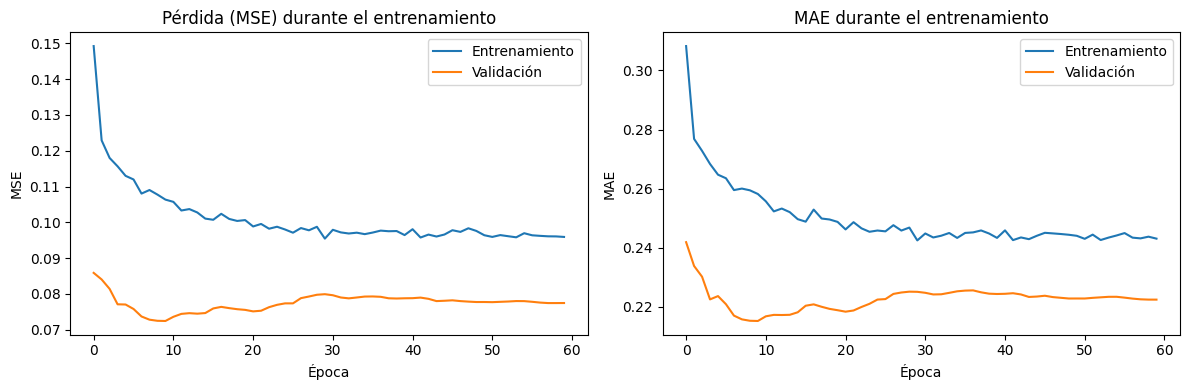

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia.history['loss'], label='Entrenamiento')
plt.plot(historia.history['val_loss'], label='Validación')
plt.title('Pérdida (MSE) durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historia.history['mae'], label='Entrenamiento')
plt.plot(historia.history['val_mae'], label='Validación')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
#plt.savefig('lstm_training_curves.png')
plt.show()

In [14]:
# Guardar modelo y escaladores
modelo.save('lstm_model_experimento.keras')
joblib.dump(scaler_X, 'scaler_X_experimento.pkl')
joblib.dump(scaler_Y, 'scaler_Y_experimento.pkl')


['scaler_Y_experimento.pkl']

In [15]:
# Realizar predicciones sobre el conjunto de prueba
Y_pred_scaled = modelo.predict(X_ts_scaled, verbose=0)

# Desescalar predicciones y valores reales
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled.reshape(-1, OUTPUT_LENGTH))
#Y_pred = Y_pred.reshape(-1, OUTPUT_LENGTH)

Y_true = scaler_Y.inverse_transform(Y_ts_scaled.reshape(-1, OUTPUT_LENGTH))
#Y_true = Y_true.reshape(-1, OUTPUT_LENGTH)

# Aplanar para métricas globales
y_true_flat = Y_true.flatten()
y_pred_flat = Y_pred.flatten()

# Calcular métricas (igual que en RF, GB, LGBM)
mae_test = mean_absolute_error(y_true_flat, y_pred_flat)
rmse_test = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
r2_test = r2_score(y_true_flat, y_pred_flat)
da_test = directional_accuracy(y_true_flat, y_pred_flat)

print("=== LSTM - RESULTADOS TEST ===")
print(f"MAE: {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²: {r2_test:.4f}")
print(f"Directional Accuracy: {da_test:.4f}")

=== LSTM - RESULTADOS TEST ===
MAE: 0.0574
RMSE: 0.0700
R²: -0.2929
Directional Accuracy: 0.5741


=== LSTM - RESULTADOS TEST ===
MAE: 0.0697
RMSE: 0.0883
R²: -0.0530
Directional Accuracy: 0.6029

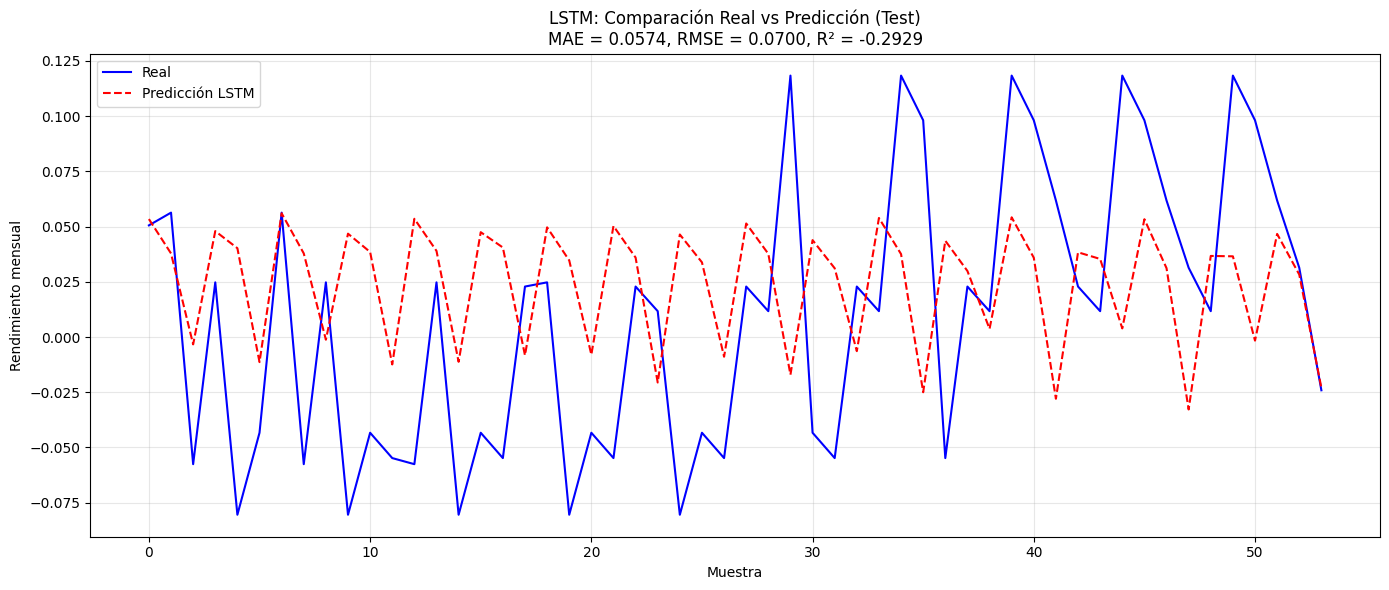

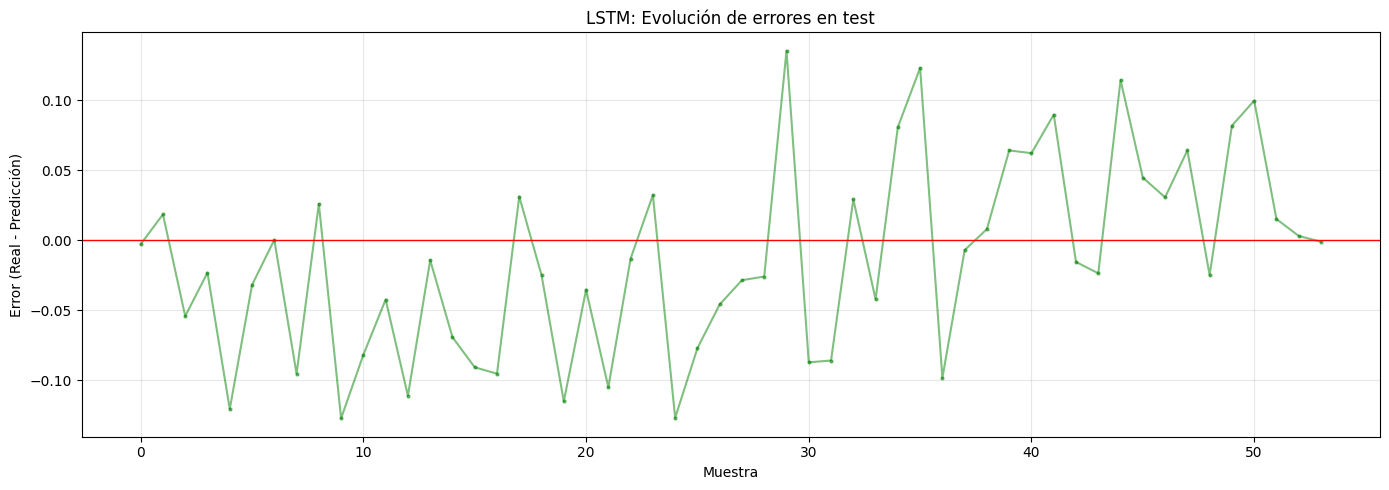

In [16]:
# Gráfica 1: Real vs Predicción
plt.figure(figsize=(14, 6))
n_mostrar = min(100, len(y_true_flat))
plt.plot(range(n_mostrar), y_true_flat[:n_mostrar], label='Real', color='blue', linewidth=1.5)
plt.plot(range(n_mostrar), y_pred_flat[:n_mostrar], label='Predicción LSTM', color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Muestra')
plt.ylabel('Rendimiento mensual')
plt.title(f'LSTM: Comparación Real vs Predicción (Test)\nMAE = {mae_test:.4f}, RMSE = {rmse_test:.4f}, R² = {r2_test:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('lstm_real_vs_pred_test.png', dpi=150)
plt.show()

# Gráfica 2: Residuos
errores = y_true_flat - y_pred_flat
plt.figure(figsize=(14, 5))
plt.plot(range(len(errores)), errores, 'o-', color='green', markersize=2, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='-', linewidth=1)
plt.xlabel('Muestra')
plt.ylabel('Error (Real - Predicción)')
plt.title('LSTM: Evolución de errores en test')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('lstm_residuos_test.png', dpi=150)
plt.show()

